# 🚢 Árbol de clasificación — Caso Titanic

## 📖 Dónde estamos
Último modelo del curso sobre el último caso. Lo que llevas:

| Modelo | Exactitud | F1 | AUC |
|---|---|---|---|
| Regla "las mujeres sobreviven" | 0.777 | 0.692 | — |
| Regresión logística | 0.771 | 0.677 | 0.837 |

> ### ❓ ¿Le gana el árbol a la regresión logística, como le ganó a la lineal en los autos?

Y al final, la pregunta que cierra el curso: **¿cómo se elige un modelo?**

## ⏱️ Agenda de la sesión (3 horas)
| Parte | Dónde | Tiempo |
|---|---|---|
| Fundamento: cómo funciona un árbol | `fundamentos.ipynb` | 30 min |
| **Caso MPG — árbol de regresión** | `caso_mpg.ipynb` | 50 min |
| ☕ Descanso | | 10 min |
| **Caso Titanic — árbol de clasificación** | `caso_titanic.ipynb` | 45 min |
| Cierre del curso: los cuatro modelos | `caso_titanic.ipynb` | 30 min |

---
# 0️⃣ Preparación

## 🛠️ Funciones auxiliares de visualización

Ejecuta la siguiente celda **una sola vez** al inicio. Después sólo tienes que **llamar** a la función que necesites:

| Función | ¿Para qué sirve? |
|---|---|
| `plot_distributions(df, columnas)` | Histograma + boxplot de variables numéricas |
| `plot_frequencies(df, columnas, top_n=None)` | Frecuencia de variables categóricas |
| `plot_correlation_matrix(df, columnas)` | Matriz de correlación |
| `plot_pairplot(df, columnas, color=None)` | Dispersión entre todas las variables numéricas |
| `plot_simple_regression(x, y, results)` | Recta ajustada de un modelo OLS con 1 variable |
| `plot_actual_vs_predicted(y_real, y_pred)` | Valores reales vs predichos |
| `plot_residuals(y_real, y_pred)` | Residuales vs predichos |
| `plot_rfecv(rfecv)` | R² según el número de variables seleccionadas por RFECV |

In [1]:
# Funciones auxiliares de visualización
# Ejecuta esta celda una vez; después sólo llama a las funciones.
import numpy as np
import plotly.express as px
import plotly.graph_objects as go


def plot_distributions(df, columns, nbins=30):
    """Histograma con boxplot marginal para cada variable numérica."""
    for col in columns:
        fig = px.histogram(
            df,
            x=col,
            nbins=nbins,
            marginal='box',
            opacity=0.7,
            title=f'Distribución de {col}'
        )
        fig.update_layout(bargap=0.2)
        fig.show()


def plot_frequencies(df, columns, top_n=None):
    """Gráfica de barras con la frecuencia de cada categoría (top_n limita a las más comunes)."""
    for col in columns:
        freq = df[col].value_counts()
        if top_n:
            freq = freq.head(top_n)
        freq_df = freq.rename_axis(col).reset_index(name='Frecuencia')

        title = f'Frecuencias de {col}'
        if top_n and df[col].nunique() > top_n:
            title += f' (top {top_n})'

        fig = px.bar(freq_df, x=col, y='Frecuencia', title=title)
        fig.update_layout(xaxis={'categoryorder': 'total descending'})
        fig.show()


def plot_correlation_matrix(df, columns):
    """Mapa de calor con la correlación de Pearson entre las variables numéricas."""
    corr = df[columns].corr().round(2)
    fig = px.imshow(
        corr,
        text_auto=True,
        color_continuous_scale='RdBu_r',
        zmin=-1,
        zmax=1,
        title='Matriz de Correlación'
    )
    fig.update_layout(width=750, height=650)
    fig.show()


def plot_pairplot(df, columns, color=None):
    """Matriz de dispersión (pairplot) entre las variables numéricas."""
    fig = px.scatter_matrix(
        df,
        dimensions=columns,
        color=color,
        title='Pairplot de Variables Numéricas',
        labels={col: col.capitalize() for col in columns}
    )
    fig.update_layout(width=1200, height=1200, title_font_size=20)
    fig.update_traces(diagonal_visible=True)
    fig.show()


def plot_simple_regression(x, y, results):
    """Dispersión de una variable vs el objetivo con la recta ajustada por un OLS de 1 variable."""
    b0, b1 = results.params.iloc[0], results.params.iloc[1]
    x_name = getattr(x, 'name', None) or 'x'
    y_name = getattr(y, 'name', None) or 'y'
    x_line = np.linspace(np.min(x), np.max(x), 100)

    fig = px.scatter(
        x=np.asarray(x),
        y=np.asarray(y),
        opacity=0.6,
        labels={'x': x_name, 'y': y_name},
        title=f'{y_name} = {b0:.2f} + ({b1:.4f}) · {x_name}',
        template='plotly_white'
    )
    fig.add_trace(go.Scatter(
        x=x_line,
        y=b0 + b1 * x_line,
        mode='lines',
        name='Recta OLS',
        line=dict(color='red', width=3)
    ))
    fig.show()


def plot_actual_vs_predicted(y_true, y_pred, title='Real vs Predicho'):
    """Valores reales vs predichos; un modelo perfecto cae sobre la diagonal roja."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())

    fig = px.scatter(
        x=y_true,
        y=y_pred,
        opacity=0.5,
        labels={'x': 'Valor real', 'y': 'Valor predicho'},
        title=title,
        template='plotly_white'
    )
    fig.add_shape(
        type='line', x0=lo, y0=lo, x1=hi, y1=hi,
        line=dict(color='red', dash='dash')
    )
    fig.show()


def plot_residuals(y_true, y_pred, title='Residuales vs Predicho'):
    """Residuales vs predichos; buscamos una nube sin patrón alrededor de 0."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)

    fig = px.scatter(
        x=y_pred,
        y=y_true - y_pred,
        opacity=0.5,
        labels={'x': 'Valor predicho', 'y': 'Residual (real − predicho)'},
        title=title,
        template='plotly_white'
    )
    fig.add_hline(y=0, line_dash='dash', line_color='red')
    fig.show()


def plot_rfecv(rfecv):
    """R² promedio de validación cruzada según el número de variables que conserva RFECV."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=rfecv.cv_results_['n_features'],
        y=rfecv.cv_results_['mean_test_score'],
        mode='lines+markers',
        line=dict(color='steelblue', width=3),
        marker=dict(size=7),
        name='R² promedio (CV)'
    ))
    fig.update_layout(
        title='RFECV — R² según número de variables seleccionadas',
        xaxis_title='Número de variables',
        yaxis_title='R² (validación cruzada)',
        template='plotly_white',
        width=900, height=450
    )
    fig.show()

### 🧰 Funciones de machine learning

Para los modelos de scikit-learn:

| Función | ¿Para qué sirve? |
|---|---|
| `escalar(X_train, X_test)` | Estandariza ambos conjuntos ajustando sólo con train |
| `evaluar_regresion(nombre, y_real, y_pred)` | R², RMSE y MAE |
| `plot_curva_k(ks, scores, metrica)` | Desempeño de validación cruzada para cada k, y regresa el mejor |
| `plot_curva_complejidad(valores, train, test, parametro, metrica)` | Entrenamiento vs prueba: así se ve el sobreajuste |
| `plot_importancias(modelo, columnas)` | Importancia de variables de un árbol |
| `plot_arbol(modelo, columnas, max_depth)` | Dibuja las reglas del árbol |

In [2]:
# Funciones de machine learning: evaluar y diagnosticar modelos de scikit-learn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import plot_tree


def evaluar_regresion(nombre, y_true, y_pred):
    """Imprime y regresa R², RMSE y MAE de un modelo de regresión."""
    metricas = {
        'modelo': nombre,
        'R²': round(r2_score(y_true, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        'MAE': round(mean_absolute_error(y_true, y_pred), 3),
    }
    print(f"{nombre}: R² {metricas['R²']} | RMSE {metricas['RMSE']} | MAE {metricas['MAE']}")
    return metricas


def escalar(X_train, X_test):
    """Estandariza (media 0, desviación 1) ajustando sólo con train. Regresa ambos DataFrames."""
    from sklearn.preprocessing import StandardScaler

    escalador = StandardScaler().fit(X_train)
    X_train_s = pd.DataFrame(escalador.transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_s = pd.DataFrame(escalador.transform(X_test), columns=X_test.columns, index=X_test.index)
    return X_train_s, X_test_s


def plot_curva_k(k_values, scores, metrica='RMSE', menor_es_mejor=True):
    """Desempeño de validación cruzada para cada valor de k en KNN."""
    k_values, scores = list(k_values), list(scores)
    mejor = k_values[int(np.argmin(scores) if menor_es_mejor else np.argmax(scores))]

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=k_values, y=scores, mode='lines+markers',
        line=dict(color='steelblue', width=3), marker=dict(size=7), name=f'{metrica} (CV)'
    ))
    fig.add_vline(x=mejor, line_dash='dash', line_color='red', annotation_text=f'mejor k = {mejor}')
    fig.update_layout(
        title=f'Elección de k — {metrica} de validación cruzada',
        xaxis_title='k (número de vecinos)', yaxis_title=f'{metrica} (validación cruzada)',
        template='plotly_white', width=900, height=450
    )
    fig.show()
    return mejor


def plot_curva_complejidad(valores, score_train, score_test, parametro='max_depth', metrica='R²'):
    """Desempeño en entrenamiento vs prueba al aumentar la complejidad: así se ve el sobreajuste."""
    datos = pd.DataFrame({parametro: list(valores) * 2,
                          metrica: list(score_train) + list(score_test),
                          'conjunto': ['Entrenamiento'] * len(score_train) + ['Prueba'] * len(score_test)})

    fig = px.line(
        datos, x=parametro, y=metrica, color='conjunto', markers=True,
        title=f'Sobreajuste: {metrica} según {parametro}', template='plotly_white',
        color_discrete_map={'Entrenamiento': 'steelblue', 'Prueba': 'tomato'}
    )
    fig.update_layout(width=900, height=450)
    fig.show()


def plot_importancias(modelo, columnas, top_n=None):
    """Importancia de cada variable en un modelo basado en árboles."""
    imp = pd.Series(modelo.feature_importances_, index=columnas).sort_values(ascending=True)
    if top_n:
        imp = imp.tail(top_n)

    fig = px.bar(
        x=imp.values, y=imp.index, orientation='h', text_auto='.3f',
        labels={'x': 'Importancia (reducción de impureza)', 'y': ''},
        title='Importancia de variables', template='plotly_white'
    )
    fig.update_layout(width=800, height=450)
    fig.show()
    return imp.sort_values(ascending=False)


def plot_arbol(modelo, columnas, max_depth=3, class_names=None):
    """Dibuja los primeros niveles del árbol para poder leer sus reglas."""
    fig, ax = plt.subplots(figsize=(22, 9))
    plot_tree(
        modelo, max_depth=max_depth, feature_names=list(columnas), class_names=class_names,
        filled=True, rounded=True, fontsize=9, impurity=False, ax=ax
    )
    ax.set_title(f'Árbol de decisión — primeros {max_depth} niveles', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 🧰 Funciones de clasificación

Ejecuta la celda una vez; después sólo llamas a la función que necesites:

| Función | ¿Para qué sirve? |
|---|---|
| `ajustar_logit(X_train, y_train)` | Ajusta una regresión logística (ya agrega la constante) |
| `predecir_proba(results, X)` | Probabilidad estimada de la clase positiva |
| `razon_de_momios(results)` | Coeficientes, razón de momios y p-value en una tabla |
| `evaluar_clasificador(nombre, y_real, y_pred)` | Exactitud, precisión, recall y F1 |
| `plot_tasa_por_categoria(df, columna, objetivo)` | Tasa de la clase positiva por categoría |
| `plot_matriz_confusion(y_real, y_pred, etiquetas)` | Matriz de confusión |
| `plot_curva_roc(y_real, y_proba)` | Curva ROC y AUC |
| `plot_metricas_por_umbral(y_real, y_proba)` | Cómo cambian las métricas al mover el umbral |
| `plot_rfecv_clasificacion(rfecv)` | Desempeño según el número de variables que elige RFECV |
| `plot_sigmoide()` | La curva que convierte cualquier número en probabilidad |

In [3]:
# Funciones de clasificación: ajustar, evaluar y diagnosticar modelos de clasificación
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import statsmodels.api as sm
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score, roc_curve)


def ajustar_logit(X_train, y_train):
    """Ajusta una regresión logística (agrega la constante automáticamente)."""
    return sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=0)


def predecir_proba(results, X):
    """Probabilidad estimada de la clase positiva, entre 0 y 1."""
    return results.predict(sm.add_constant(X))


def razon_de_momios(results):
    """Coeficientes en log-odds, su razón de momios (odds ratio) y el p-value."""
    return pd.DataFrame({
        'coef (log-odds)': results.params.round(4),
        'razón de momios': np.exp(results.params).round(3),
        'p-value': results.pvalues.round(4),
    })


def evaluar_clasificador(nombre, y_true, y_pred):
    """Imprime y regresa exactitud, precisión, recall y F1."""
    metricas = {
        'modelo': nombre,
        'exactitud': round(accuracy_score(y_true, y_pred), 3),
        'precisión': round(precision_score(y_true, y_pred, zero_division=0), 3),
        'recall': round(recall_score(y_true, y_pred, zero_division=0), 3),
        'F1': round(f1_score(y_true, y_pred, zero_division=0), 3),
    }
    print(f"{nombre}: exactitud {metricas['exactitud']} | precisión {metricas['precisión']} "
          f"| recall {metricas['recall']} | F1 {metricas['F1']}")
    return metricas


def plot_tasa_por_categoria(df, columna, objetivo):
    """Proporción de la clase positiva dentro de cada categoría."""
    tasa = df.groupby(columna, as_index=False)[objetivo].mean()

    fig = px.bar(
        tasa,
        x=columna,
        y=objetivo,
        text_auto='.1%',
        title=f'Tasa de {objetivo} por {columna}',
        template='plotly_white'
    )
    fig.update_layout(yaxis_tickformat='.0%', yaxis_title=f'Tasa de {objetivo}', width=700, height=450)
    fig.update_xaxes(type='category')
    fig.show()


def plot_matriz_confusion(y_true, y_pred, etiquetas=('No', 'Sí'), title='Matriz de confusión'):
    """Aciertos y errores del clasificador: la diagonal son los aciertos."""
    cm = pd.DataFrame(
        confusion_matrix(y_true, y_pred),
        index=[f'Real: {e}' for e in etiquetas],
        columns=[f'Predicho: {e}' for e in etiquetas]
    )

    fig = px.imshow(cm, text_auto=True, color_continuous_scale='Blues', title=title)
    fig.update_layout(width=650, height=450)
    fig.show()


def plot_curva_roc(y_true, y_proba, title='Curva ROC'):
    """Compromiso entre verdaderos y falsos positivos al mover el umbral."""
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr, mode='lines', name=f'Modelo (AUC = {auc:.3f})',
        line=dict(color='steelblue', width=3)
    ))
    fig.add_trace(go.Scatter(
        x=[0, 1], y=[0, 1], mode='lines', name='Azar (AUC = 0.5)',
        line=dict(color='red', dash='dash')
    ))
    fig.update_layout(
        title=title,
        xaxis_title='Falsos positivos (1 − especificidad)',
        yaxis_title='Verdaderos positivos (recall)',
        template='plotly_white', width=700, height=550
    )
    fig.show()


def plot_metricas_por_umbral(y_true, y_proba):
    """Cómo cambian exactitud, precisión, recall y F1 según el umbral de decisión."""
    umbrales = np.arange(0.05, 0.96, 0.05)
    filas = []
    for u in umbrales:
        y_pred = (y_proba >= u).astype(int)
        filas.append({
            'umbral': round(u, 2),
            'exactitud': accuracy_score(y_true, y_pred),
            'precisión': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'F1': f1_score(y_true, y_pred, zero_division=0),
        })

    datos = pd.DataFrame(filas).melt(id_vars='umbral', var_name='métrica', value_name='valor')

    fig = px.line(
        datos, x='umbral', y='valor', color='métrica', markers=True,
        title='Métricas según el umbral de decisión', template='plotly_white'
    )
    fig.add_vline(x=0.5, line_dash='dash', line_color='gray', annotation_text='umbral por defecto')
    fig.update_layout(width=900, height=500)
    fig.show()


def plot_rfecv_clasificacion(rfecv, metrica='exactitud'):
    """Desempeño promedio de validación cruzada según el número de variables que conserva RFECV."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=rfecv.cv_results_['n_features'],
        y=rfecv.cv_results_['mean_test_score'],
        mode='lines+markers',
        line=dict(color='steelblue', width=3),
        marker=dict(size=7),
        name=f'{metrica} promedio (CV)'
    ))
    fig.add_vline(x=rfecv.n_features_, line_dash='dash', line_color='red',
                  annotation_text=f'elegido: {rfecv.n_features_}')
    fig.update_layout(
        title='RFECV — desempeño según número de variables seleccionadas',
        xaxis_title='Número de variables',
        yaxis_title=f'{metrica.capitalize()} (validación cruzada)',
        template='plotly_white', width=900, height=450
    )
    fig.show()


def plot_sigmoide():
    """La función que convierte cualquier número en una probabilidad entre 0 y 1."""
    z = np.linspace(-8, 8, 200)

    fig = px.line(
        x=z, y=1 / (1 + np.exp(-z)),
        labels={'x': 'z = β₀ + β₁x₁ + β₂x₂ + …', 'y': 'Probabilidad estimada'},
        title='Función sigmoide (logística)', template='plotly_white'
    )
    fig.add_hline(y=0.5, line_dash='dash', line_color='red', annotation_text='umbral 0.5')
    fig.add_vline(x=0, line_dash='dot', line_color='gray')
    fig.update_traces(line=dict(color='steelblue', width=3))
    fig.update_layout(width=800, height=450)
    fig.show()

### 📥 Los datos, ya preparados

Este caso lo trabajaste en la sesión de regresión logística, así que no repetimos la exploración ni el preprocesamiento: la celda siguiente trae las dos funciones que hacen lo mismo que hiciste a mano.

| Función | ¿Qué hace? |
|---|---|
| `cargar_titanic()` | Descarga la base SQLite con los 891 pasajeros |
| `preparar_titanic(df)` | Split estratificado 80/20, imputa `age` y `embarked` con datos de train, crea `viaja_solo` y `es_menor`, y codifica las categóricas |

Usa exactamente la **misma partición** de aquella sesión, así que las métricas son comparables.

In [4]:
# Datos del caso Titanic: carga y preparación (idénticas a las de la sesión 2)
import numpy as np
import pandas as pd
import requests
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder


def cargar_titanic():
    """Descarga la base SQLite del caso Titanic y regresa el DataFrame (891 pasajeros)."""
    url = "https://raw.githubusercontent.com/davidjamesknight/SQLite_databases_for_learning_data_science/main/titanic.db"
    with open("titanic.db", "wb") as f:
        f.write(requests.get(url).content)

    query = """
    SELECT
        O.survived,
        O.pclass,
        O.age,
        O.sibsp,
        O.parch,
        O.fare,
        O.adult_male,
        O.alone,
        S.sex,
        E.embarked
    FROM
        Observation AS O
    JOIN
        Sex AS S ON O.sex_id = S.sex_id
    JOIN
        Embarked AS E ON O.embarked_id = E.embarked_id
    """
    return pd.read_sql_query(query, sqlite3.connect("titanic.db"))


def preparar_titanic(df, test_size=0.2, random_state=42):
    """Split estratificado 80/20, imputación con datos de train, variables nuevas y dummies.

    Replica la sesión 2: se imputa 'age' con la mediana y 'embarked' con la moda (ambas de train),
    se crean 'viaja_solo' y 'es_menor', y las referencias de las dummies son 3ª clase,
    Southampton y mujer. Regresa X_train, X_test, y_train, y_test listos para modelar.
    """
    X = df.drop(columns=['survived', 'adult_male', 'alone'])
    y = df['survived']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    mediana_edad = X_train['age'].median()
    moda_puerto = X_train['embarked'].mode()[0]

    preparados = []
    for datos in (X_train, X_test):
        datos = datos.copy()
        datos['age'] = datos['age'].fillna(mediana_edad)
        datos['embarked'] = datos['embarked'].fillna(moda_puerto)
        datos['viaja_solo'] = np.where(datos['sibsp'] + datos['parch'] > 0, 0, 1)
        datos['es_menor'] = np.where(datos['age'] <= 16, 1, 0)
        preparados.append(datos.drop(columns=['sibsp', 'parch']))

    X_train_prep, X_test_prep = preparados
    categoricas = ['pclass', 'embarked', 'sex']

    ohe = OneHotEncoder(drop=[3, 'S', 'female'], sparse_output=False)
    dummies_train = pd.DataFrame(
        ohe.fit_transform(X_train_prep[categoricas]),
        columns=ohe.get_feature_names_out(), index=X_train_prep.index
    )
    dummies_test = pd.DataFrame(
        ohe.transform(X_test_prep[categoricas]),
        columns=ohe.get_feature_names_out(), index=X_test_prep.index
    )

    X_train_enc = pd.concat([X_train_prep.drop(columns=categoricas), dummies_train], axis=1)
    X_test_enc = pd.concat([X_test_prep.drop(columns=categoricas), dummies_test], axis=1)

    print(f"Train: {X_train_enc.shape} | Test: {X_test_enc.shape}")
    print(f"Variables: {list(X_train_enc.columns)}")
    return X_train_enc, X_test_enc, y_train, y_test

In [5]:
df = cargar_titanic()
X_train, X_test, y_train, y_test = preparar_titanic(df)

Train: (712, 9) | Test: (179, 9)
Variables: ['age', 'fare', 'viaja_solo', 'es_menor', 'pclass_1', 'pclass_2', 'embarked_C', 'embarked_Q', 'sex_male']


---
# 1️⃣ Podar el árbol (20 min)

Lo mismo que en el caso MPG, cambiando sólo el criterio: ahora buscamos **exactitud** en vez de RMSE.

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

parametros = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10, None],
    'min_samples_leaf': [1, 5, 10, 20]
}

busqueda = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    parametros,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)
busqueda.fit(X_train, y_train)

arbol = busqueda.best_estimator_

print(f"Mejores parámetros: {busqueda.best_params_}")
print(f"Exactitud de validación cruzada: {busqueda.best_score_:.4f}")

Mejores parámetros: {'max_depth': 6, 'min_samples_leaf': 5}
Exactitud de validación cruzada: 0.8118


In [7]:
pred_arbol = arbol.predict(X_test)
proba_arbol = arbol.predict_proba(X_test)[:, 1]

comparacion = []
comparacion.append(evaluar_clasificador('Árbol podado', y_test, pred_arbol))

print(f"Exactitud en entrenamiento: {arbol.score(X_train, y_train):.3f} | Hojas: {arbol.get_n_leaves()}")

Árbol podado: exactitud 0.765 | precisión 0.765 | recall 0.565 | F1 0.65
Exactitud en entrenamiento: 0.857 | Hojas: 29


In [8]:
plot_matriz_confusion(y_test, pred_arbol, etiquetas=('No sobrevivió', 'Sobrevivió'),
                      title='Árbol de decisión — Matriz de confusión')

✅ **Exactitud 0.765 en prueba**, contra 0.857 en entrenamiento: todavía hay algo de sobreajuste, aunque mucho menos que sin podar.

Queda **por debajo de la logística** (0.771) y de la regla simple (0.777), aunque los tres están **a menos de dos puntos de distancia**: en 179 pasajeros de prueba, eso son apenas 2 personas.

🤔 **Ojo con lo que acaba de pasar:** el mismo algoritmo que en los autos le ganó a la regresión lineal, aquí pierde contra la logística. Guarda esa idea para el cierre.

---
# 2️⃣ Leer el árbol (15 min)

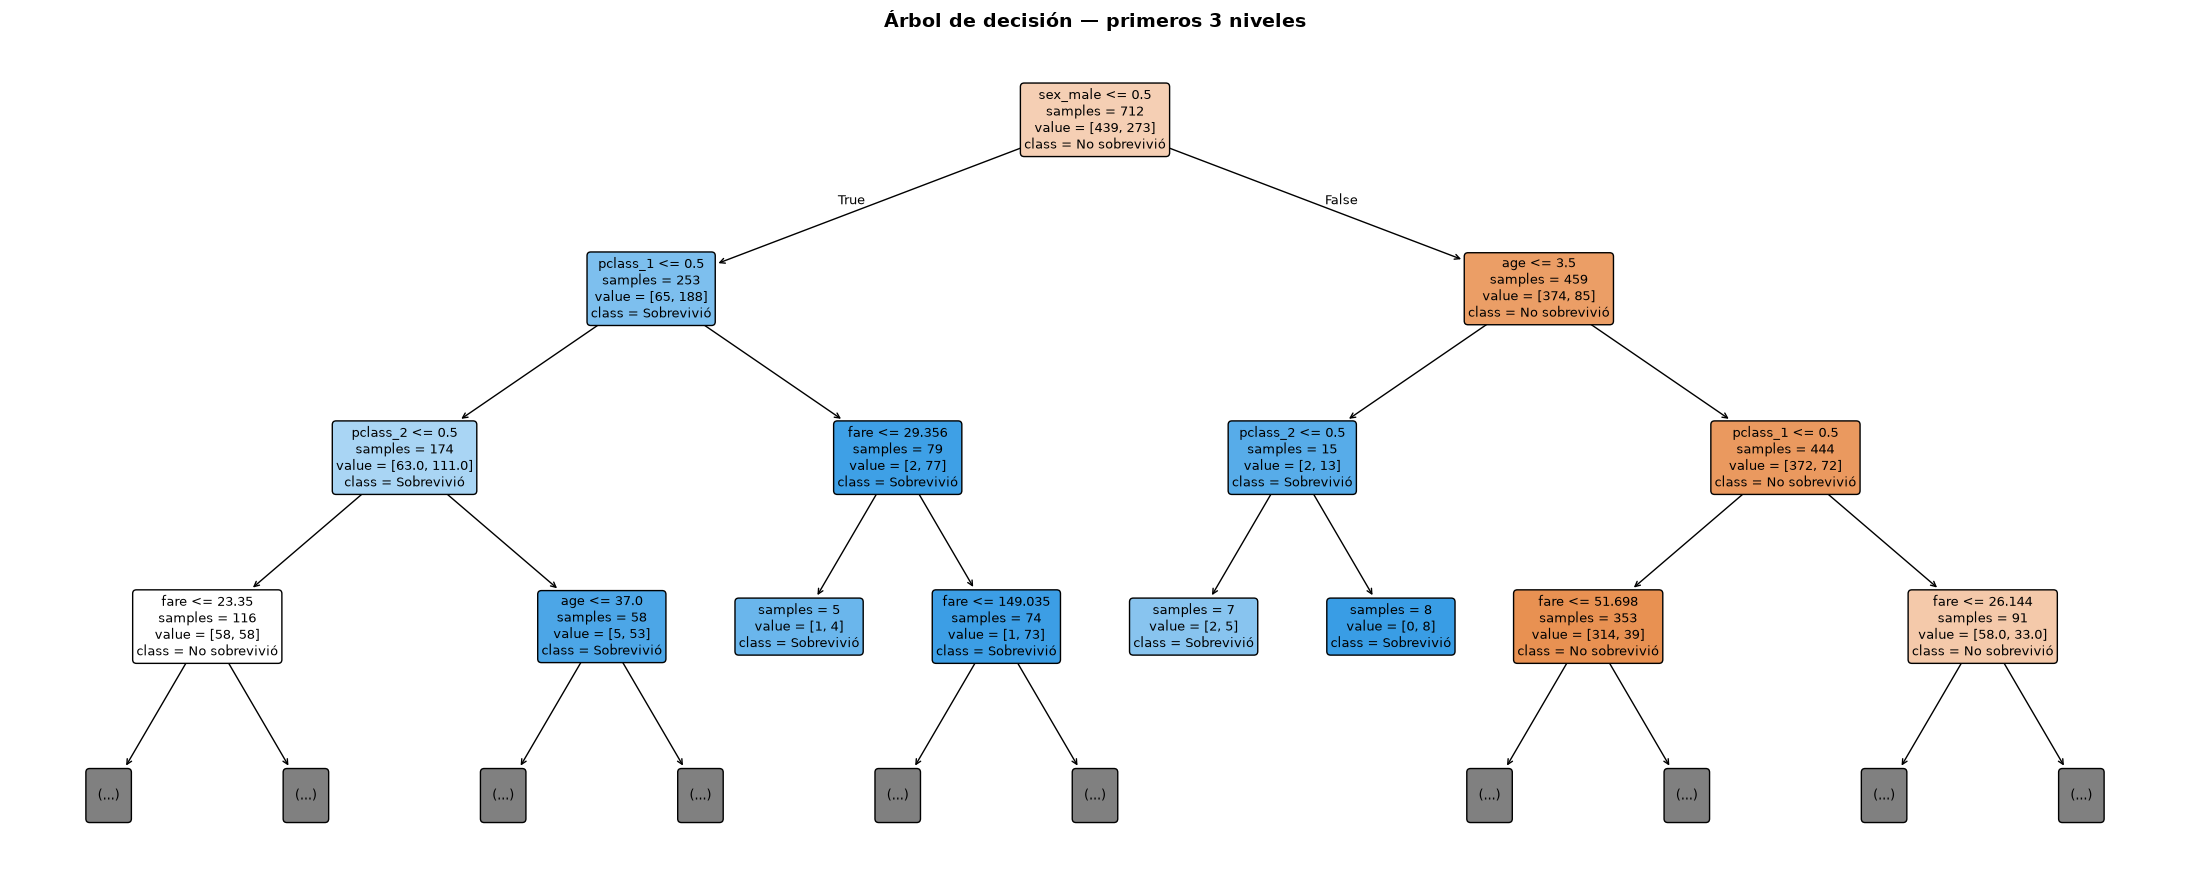

In [9]:
plot_arbol(arbol, X_train.columns, max_depth=3, class_names=['No sobrevivió', 'Sobrevivió'])

In [10]:
importancias = plot_importancias(arbol, X_train.columns)

✅ **Qué observar:**
- El primer corte es **`sex_male`**, con el **54.3%** de la importancia. El árbol, por su cuenta, redescubrió la regla histórica de "mujeres y niños primero" y el coeficiente más fuerte de la logística
- Le siguen `fare` (15.2%), `pclass_1` (11.5%) y `age` (11.2%)

🤔 **Pero `fare` no era significativa en la logística** (p = 0.767). ¿Por qué aquí pesa tanto?

Porque `fare` y `pclass` dicen casi lo mismo (correlación -0.55). La logística, al tener ambas, le dio el crédito a la clase y descartó la tarifa. El árbol, en cambio, usa `fare` para hacer **cortes finos dentro** de cada clase: entre los de tercera, los que pagaron más tenían mejores camarotes. Es otra vez el reparto arbitrario entre variables correlacionadas.

---
# 3️⃣ Una trampa que hay que ver (10 min)

Comparemos el árbol podado contra uno sin podar, pero mirando **las dos** métricas.

In [11]:
arbol_sin_podar = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)

print(f"Sin podar  — entrenamiento: {arbol_sin_podar.score(X_train, y_train):.3f} | prueba: {arbol_sin_podar.score(X_test, y_test):.3f}")
print(f"Podado     — entrenamiento: {arbol.score(X_train, y_train):.3f} | prueba: {arbol.score(X_test, y_test):.3f}")
print(f"Validación cruzada (lo que usamos para elegir): {busqueda.best_score_:.3f}")

Sin podar  — entrenamiento: 0.983 | prueba: 0.832
Podado     — entrenamiento: 0.857 | prueba: 0.765
Validación cruzada (lo que usamos para elegir): 0.812


😳 **El árbol sin podar sacó mejor exactitud en prueba que el podado.** ¿Entonces nos equivocamos al podar?

**No.** Mira las tres cifras juntas:
- Sin podar acierta **98.3%** en entrenamiento: está memorizando, de eso no hay duda
- Su validación cruzada es peor que la del podado, y ésa es la estimación honesta, hecha con 5 particiones distintas
- El conjunto de prueba tiene **179 pasajeros**: una diferencia de 2 puntos son 3 personas, perfectamente atribuible al azar

> ### 💡 La regla que esto enseña
> **Los hiperparámetros se eligen con validación cruzada, nunca mirando el conjunto de prueba.** Si eliges el modelo que mejor sale en prueba, ese número deja de ser una estimación honesta: se convierte en otro conjunto de entrenamiento disfrazado.

Si en tu trabajo ves a alguien probando modelos hasta que "sale bien en test", acabas de aprender por qué eso no vale.

---
# 4️⃣ Cierre del curso: los cuatro modelos (30 min)

Hora de juntar todo el curso en una tabla.

In [12]:
import pandas as pd

resumen = pd.DataFrame([
    {'caso': 'MPG (regresión)', 'modelo': 'Regresión lineal (RFE)', 'desempeño': 0.794, 'métrica': 'R²',
     'interpretable': 'Alta', 'escalado': 'No'},
    {'caso': 'MPG (regresión)', 'modelo': 'Árbol podado', 'desempeño': 0.812, 'métrica': 'R²',
     'interpretable': 'Media', 'escalado': 'No'},
    {'caso': 'Titanic (clasificación)', 'modelo': 'Regresión logística', 'desempeño': 0.771, 'métrica': 'Exactitud',
     'interpretable': 'Alta', 'escalado': 'No'},
    {'caso': 'Titanic (clasificación)', 'modelo': 'Regla "mujeres sobreviven"', 'desempeño': 0.777, 'métrica': 'Exactitud',
     'interpretable': 'Total', 'escalado': 'No'},
    {'caso': 'Titanic (clasificación)', 'modelo': 'Árbol podado', 'desempeño': 0.765, 'métrica': 'Exactitud',
     'interpretable': 'Media', 'escalado': 'No'},
])

resumen

,caso,modelo,desempeño,métrica,interpretable,escalado
0,MPG (regresión),Regresión lineal (RFE),0.794,R²,Alta,No
1,MPG (regresión),Árbol podado,0.812,R²,Media,No
2,Titanic (clasificación),Regresión logística,0.771,Exactitud,Alta,No
3,Titanic (clasificación),"Regla ""mujeres sobreviven""",0.777,Exactitud,Total,No
4,Titanic (clasificación),Árbol podado,0.765,Exactitud,Media,No


## ❓ La pregunta que cierra el curso
> *¿Cuál es el mejor modelo?*

**Ninguno.** Mira la tabla: en los autos el árbol le ganó a la recta; en los pasajeros la regresión logística le ganó al árbol, y hasta una regla de una línea quedó arriba de los dos.

Lo que cambió no fue el algoritmo, fueron **los datos**:

| En MPG | En Titanic |
|---|---|
| Variables numéricas continuas | 6 de 9 variables son dummies de 0 y 1 |
| Relación curva entre peso y rendimiento | Relación casi lineal en log-odds |
| Gana el modelo **flexible** (árbol) | Gana el modelo **simple** (logística) |

### Cómo elegir, en la práctica
1. **Empieza por el modelo simple.** Es tu punto de comparación, y muchas veces es suficiente
2. **Pregunta para qué es el modelo.** ¿Para predecir, o para explicar? Hay modelos que predicen mejor pero no pueden justificar una decisión, y eso los descarta si un regulador o un jefe va a preguntarte *por qué*
3. **Mide siempre contra algo tonto.** La regla "las mujeres sobreviven" le ganó a tres modelos
4. **Elige con validación cruzada**, no con el conjunto de prueba
5. **Diferencias de uno o dos puntos no son diferencias.** Con 179 casos de prueba, eso es ruido

## 📝 Lo que aprendimos hoy
1. El árbol hace **preguntas binarias**; no necesita escalado y **se puede dibujar**
2. **Sin podar, memoriza**: 1.000 de R² en entrenamiento en el caso MPG
3. `max_depth` y `min_samples_leaf` se eligen con **validación cruzada**
4. La **importancia de variables** se reparte de forma arbitraria entre variables correlacionadas: `displacement` se llevó el crédito de `weight`
5. Nunca elijas hiperparámetros mirando el conjunto de prueba

## 🚀 Retos opcionales
- Prueba `DecisionTreeClassifier(criterion='entropy')` en lugar de Gini. ¿Cambia el árbol? ¿Cambia la exactitud?
- Ajusta un árbol usando sólo `sex_male` y `pclass_1`. ¿Cuánto pierdes contra el árbol completo?
- Entra a `extra/diamonds/` y corre sobre ese caso los modelos que ya conoces. ¿Cuál gana ahí, y qué te dice eso sobre la forma de esos datos?

> 📌 **Siguiente paso:** en `04-knn/`, que trabajarás de forma **asincrónica**, agregarás un cuarto modelo a esta tabla: K-Nearest Neighbors. Ahí verás que vuelve a cambiar quién gana.